# 📊 Exploratory Data Analysis - Customer Churn Prediction

## 🎯 Objectif
Analyser en profondeur le dataset de churn client pour identifier les patterns, les corrélations, et les facteurs influençant la résiliation.

## 📋 Structure du Notebook
1. Imports et configuration
2. Chargement et exploration initiale
3. Analyse des features (numériques et catégorielles)
4. Vérification du déséquilibre des classes
5. Visualisations des distributions
6. Analyse des corrélations
7. Extraction de X et y
8. Conclusions et recommandations

## 1️⃣ Imports Required Libraries

In [12]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Add src to path for importing DataProcessor
import sys
sys.path.insert(0, '../src')
from data_processing import DataProcessor

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Load and Explore the Dataset

In [13]:
# Initialize DataProcessor and load data
data_path = "/Users/amayasbariz/Documents/dossier sans titre/projet ds/churn/data/customer_churn_business_dataset.csv"
processor = DataProcessor(data_path)
df = processor.load_data()

# Display initial exploration
processor.explore_data()

✅ Dataset chargé : 10000 clients, 32 features

EXPLORATION INITIALE DES DONNÉES

📊 Dimensions : (10000, 32)

🔍 Types de données :
customer_id                   str
gender                        str
age                         int64
country                       str
city                          str
customer_segment              str
tenure_months               int64
signup_channel                str
contract_type                 str
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method                str
payment_failures            int64
discount_applied              str
price_increase_last_3m        str
support_tickets             int64
avg_resolution_time       float64
complaint_type                str
csat_score                float64
escalations         

## 3️⃣ Analyze Feature Types and Distributions

In [14]:
# Identify feature types
numerical_features, categorical_features = processor.identify_features("churn")

print(f"\n📊 RÉSUMÉ DES FEATURES")
print(f"{'='*70}")
print(f"Total features: {len(numerical_features) + len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"\n✅ Features identifiées avec succès!")


📊 Features numériques (19) : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time']...
📊 Features catégorielles (12) : ['customer_id', 'gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']
🎯 Variable cible : churn

📊 RÉSUMÉ DES FEATURES
Total features: 31
Numerical features: 19
Categorical features: 12

✅ Features identifiées avec succès!


## 4️⃣ Check Class Balance

In [15]:
# Check class balance
class_dist = processor.check_class_balance("churn")

# Visualize with Plotly
churn_counts = df['churn'].value_counts()
fig = go.Figure(data=[
    go.Bar(
        x=['No Churn (0)', 'Churn (1)'],
        y=churn_counts.values,
        text=[f"{v}<br>({v/len(df)*100:.1f}%)" for v in churn_counts.values],
        textposition='auto',
        marker=dict(color=['#2ecc71', '#e74c3c'])
    )
])
fig.update_layout(
    title="Distribution of Churn Classes",
    yaxis_title="Number of Customers",
    xaxis_title="Churn Status",
    showlegend=False,
    height=400
)
fig.show()

# Alert on class imbalance
if class_dist.get(1, 0) < 30:
    print("\n⚠️ ATTENTION: Classe minoritaire très déséquilibrée!")
    print("   Nous devrons utiliser des stratégies comme SMOTE ou class_weight")
else:
    print("\n✅ Distribution des classes acceptable")


⚖️ Distribution des classes (churn) :
   Classe 0: 89.79%
   Classe 1: 10.21%



⚠️ ATTENTION: Classe minoritaire très déséquilibrée!
   Nous devrons utiliser des stratégies comme SMOTE ou class_weight


## 5️⃣ Visualize Numerical Features

In [16]:
# Create histograms for numerical features
fig = make_subplots(
    rows=(len(numerical_features) + 2) // 3,
    cols=3,
    subplot_titles=numerical_features,
    specs=[[{"secondary_y": False}] * 3 for _ in range((len(numerical_features) + 2) // 3)]
)

for idx, feature in enumerate(numerical_features):
    row = idx // 3 + 1
    col = idx % 3 + 1
    
    fig.add_trace(
        go.Histogram(x=df[feature], name=feature, nbinsx=30, marker_color='#3498db'),
        row=row, col=col
    )

fig.update_layout(height=300 * ((len(numerical_features) + 2) // 3), showlegend=False, title_text="Distributions des Features Numériques")
fig.show()

print("✅ Histograms for numerical features created")

✅ Histograms for numerical features created


In [17]:
# Box plots for numerical features (top 10 most important)
top_numerical = numerical_features[:10] if len(numerical_features) > 10 else numerical_features

fig = make_subplots(
    rows=(len(top_numerical) + 2) // 3,
    cols=3,
    subplot_titles=top_numerical,
    specs=[[{"secondary_y": False}] * 3 for _ in range((len(top_numerical) + 2) // 3)]
)

for idx, feature in enumerate(top_numerical):
    row = idx // 3 + 1
    col = idx % 3 + 1
    
    fig.add_trace(
        go.Box(y=df[feature], name=feature, marker_color='#9b59b6'),
        row=row, col=col
    )

fig.update_layout(height=300 * ((len(top_numerical) + 2) // 3), showlegend=False, title_text="Box Plots des Features Numériques")
fig.show()

print("✅ Box plots created")

✅ Box plots created


## 6️⃣ Visualize Categorical Features

In [18]:
# Create bar plots for categorical features (top 8)
top_categorical = categorical_features[:8] if len(categorical_features) > 8 else categorical_features

fig = make_subplots(
    rows=(len(top_categorical) + 1) // 2,
    cols=2,
    subplot_titles=top_categorical,
    specs=[[{"secondary_y": False}] * 2 for _ in range((len(top_categorical) + 1) // 2)]
)

for idx, feature in enumerate(top_categorical):
    row = idx // 2 + 1
    col = idx % 2 + 1
    
    value_counts = df[feature].value_counts()
    fig.add_trace(
        go.Bar(x=value_counts.index, y=value_counts.values, name=feature, marker_color='#e67e22'),
        row=row, col=col
    )

fig.update_layout(height=250 * ((len(top_categorical) + 1) // 2), showlegend=False, title_text="Distributions des Features Catégorielles")
fig.show()

print("✅ Bar plots for categorical features created")

✅ Bar plots for categorical features created


## 7️⃣ Correlation Analysis

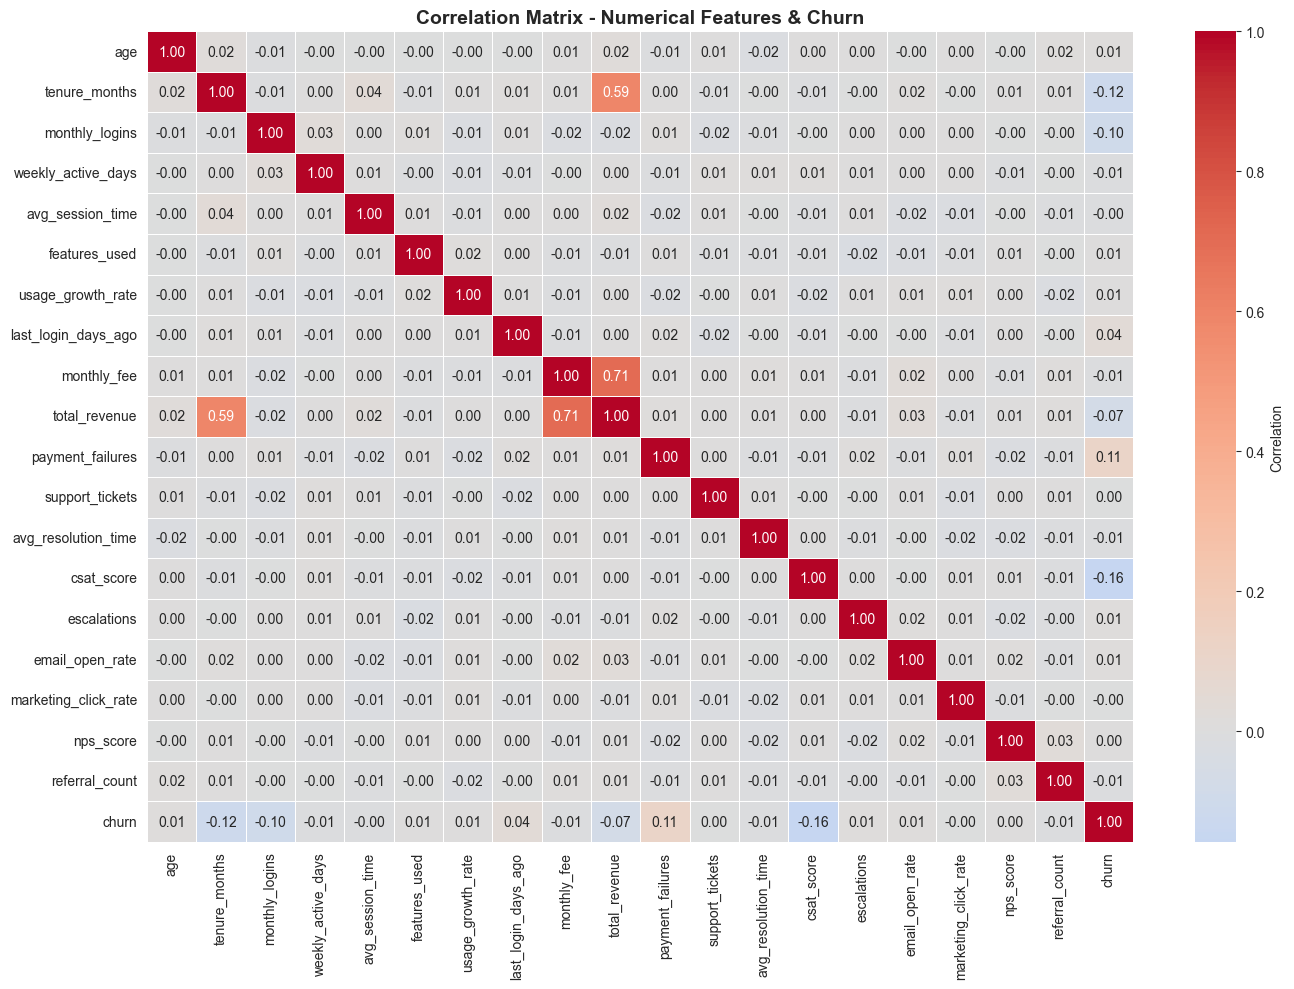

✅ Correlation matrix created


In [19]:
# Compute correlation matrix
corr_matrix = df[numerical_features + ['churn']].corr()

# Heatmap with Seaborn
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, linewidths=0.5)
plt.title('Correlation Matrix - Numerical Features & Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Correlation matrix created")

In [20]:
# Find features most correlated with churn
churn_corr = corr_matrix['churn'].drop('churn').sort_values(ascending=False)

print("\n📊 TOP FEATURES CORRELÉES AVEC LE CHURN")
print("="*70)
print("\n✅ Corrélations positives (plus corrélées = plus de churn):")
print(churn_corr[churn_corr > 0].head(10))

print("\n⚠️ Corrélations négatives (moins corrélées = moins de churn):")
print(churn_corr[churn_corr < 0].head(10))

# Visualization
fig = go.Figure(data=[
    go.Bar(
        x=churn_corr.values[:15],
        y=churn_corr.index[:15],
        orientation='h',
        marker=dict(color=['#e74c3c' if v > 0 else '#2ecc71' for v in churn_corr.values[:15]])
    )
])
fig.update_layout(
    title="Top 15 Features Correlated with Churn",
    xaxis_title="Correlation Coefficient",
    height=400
)
fig.show()


📊 TOP FEATURES CORRELÉES AVEC LE CHURN

✅ Corrélations positives (plus corrélées = plus de churn):
payment_failures       0.112494
last_login_days_ago    0.037250
email_open_rate        0.011506
age                    0.010155
escalations            0.009561
features_used          0.005435
usage_growth_rate      0.005276
nps_score              0.002996
support_tickets        0.000317
Name: churn, dtype: float64

⚠️ Corrélations négatives (moins corrélées = moins de churn):
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
total_revenue          -0.070120
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64


## 8️⃣ Extract Features and Target

In [21]:
# Extract X and y
X, y = processor.get_X_y("churn")

# Display first few rows
print("\n📊 PREMIER APERÇU DE X ET Y")
print("="*70)
print("\n✅ Première ligne de X :")
print(X.head(1))
print("\n✅ Distribution de y :")
print(y.value_counts())
print("\n✅ Statistiques de y :")
print(f"   - Churn rate: {y.sum() / len(y) * 100:.2f}%")
print(f"   - Non-churn rate: {(1 - y.sum() / len(y)) * 100:.2f}%")

✅ X shape: (10000, 31), y shape: (10000,)

📊 PREMIER APERÇU DE X ET Y

✅ Première ligne de X :
  customer_id gender  age     country    city customer_segment  tenure_months  \
0  CUST_00001   Male   68  Bangladesh  London              SME             22   

  signup_channel contract_type  monthly_logins  weekly_active_days  \
0            Web       Monthly              26                   7   

   avg_session_time  features_used  usage_growth_rate  last_login_days_ago  \
0         11.762372              5               0.06                    7   

   monthly_fee  total_revenue payment_method  payment_failures  \
0           30            660         PayPal                 1   

  discount_applied price_increase_last_3m  support_tickets  \
0              Yes                     No                4   

   avg_resolution_time complaint_type  csat_score  escalations  \
0             13.35436        Service         4.0            0   

   email_open_rate  marketing_click_rate  nps_score s

## 📝 Conclusions et Recommandations

In [22]:
print("\n" + "="*70)
print("📋 RÉSUMÉ DE L'ANALYSE EXPLORATOIRE")
print("="*70)

print("\n✅ OBSERVATIONS CLÉS:")
print(f"\n1. DONNÉES:")
print(f"   - Total clients: {len(df):,}")
print(f"   - Nombre de features: {len(numerical_features) + len(categorical_features)}")
print(f"   - Features numériques: {len(numerical_features)}")
print(f"   - Features catégorielles: {len(categorical_features)}")
print(f"   - Valeurs manquantes: {df.isnull().sum().sum()}")

print(f"\n2. DÉSÉQUILIBRE DES CLASSES:")
churn_pct = y.sum() / len(y) * 100
print(f"   - Taux de churn: {churn_pct:.2f}%")
print(f"   - Taux de rétention: {100 - churn_pct:.2f}%")
if churn_pct < 30:
    print(f"   ⚠️ DÉSÉQUILIBRE IMPORTANT - Utiliser SMOTE ou class_weight")

print(f"\n3. FEATURES LES PLUS CORRÉLÉES AVEC CHURN:")
for feat, corr in churn_corr.head(5).items():
    print(f"   - {feat}: {corr:.4f}")

print(f"\n4. RECOMMANDATIONS POUR LA MODÉLISATION:")
print("   - Utiliser stratified train/test split")
if churn_pct < 30:
    print("   - Considérer SMOTE pour équilibrer les classes")
print("   - Standardiser les features numériques")
print("   - Encoder les variables catégorielles (One-Hot ou Label Encoding)")
print("   - Tester plusieurs modèles: Logistic Regression, Random Forest, XGBoost, MLP")
print("   - Utiliser les métriques: Accuracy, Precision, Recall, F1, ROC-AUC")
print("   - Appliquer SHAP pour l'explicabilité")

print("\n" + "="*70)
print("✅ EDA COMPLÈTE - PRÊT POUR LA MODÉLISATION")
print("="*70)


📋 RÉSUMÉ DE L'ANALYSE EXPLORATOIRE

✅ OBSERVATIONS CLÉS:

1. DONNÉES:
   - Total clients: 10,000
   - Nombre de features: 31
   - Features numériques: 19
   - Features catégorielles: 12
   - Valeurs manquantes: 2045

2. DÉSÉQUILIBRE DES CLASSES:
   - Taux de churn: 10.21%
   - Taux de rétention: 89.79%
   ⚠️ DÉSÉQUILIBRE IMPORTANT - Utiliser SMOTE ou class_weight

3. FEATURES LES PLUS CORRÉLÉES AVEC CHURN:
   - payment_failures: 0.1125
   - last_login_days_ago: 0.0373
   - email_open_rate: 0.0115
   - age: 0.0102
   - escalations: 0.0096

4. RECOMMANDATIONS POUR LA MODÉLISATION:
   - Utiliser stratified train/test split
   - Considérer SMOTE pour équilibrer les classes
   - Standardiser les features numériques
   - Encoder les variables catégorielles (One-Hot ou Label Encoding)
   - Tester plusieurs modèles: Logistic Regression, Random Forest, XGBoost, MLP
   - Utiliser les métriques: Accuracy, Precision, Recall, F1, ROC-AUC
   - Appliquer SHAP pour l'explicabilité

✅ EDA COMPLÈTE - P